# 🤗 Sentiment Analysis via Transfer Learning (Transformer)

Fine-tune **DistilBERT** on a 3-class sentiment dataset (Positive / Neutral / Negative).

## Pipeline
1. Download the Kaggle dataset
2. Explore & clean the data
3. Tokenise with DistilBERT tokeniser
4. Fine-tune the pre-trained model
5. Evaluate — classification report + confusion matrix

> ⚡ **Enable GPU:** `Runtime → Change runtime type → T4 GPU`

## Step 1 — Install Dependencies

In [ ]:
!pip install -q kaggle transformers datasets accelerate scikit-learn seaborn matplotlib

## Step 2 — Kaggle Authentication & Dataset Download

You need a **Kaggle API key** (`kaggle.json`).  
Get it from: https://www.kaggle.com/settings → **API → Create New Token**

In [ ]:
import os
from google.colab import files

# Upload kaggle.json when prompted
print('Upload your kaggle.json file:')
uploaded = files.upload()

# Place it where the Kaggle CLI expects it
os.makedirs('/root/.config/kaggle', exist_ok=True)
!cp kaggle.json /root/.config/kaggle/kaggle.json
!chmod 600 /root/.config/kaggle/kaggle.json
print('Kaggle credentials configured')

In [2]:
!kaggle datasets download -d abhi8923shriv/sentiment-analysis-dataset --unzip -p ./data
!ls ./data

Dataset URL: https://www.kaggle.com/datasets/abhi8923shriv/sentiment-analysis-dataset
License(s): CC0-1.0
100% 54.4M/54.4M [00:00<00:00, 186MB/s]

test.csv			train.csv
testdata.manual.2009.06.14.csv	training.1600000.processed.noemoticon.csv


## Step 3 — Imports & Reproducibility

In [3]:
import warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU   : {torch.cuda.get_device_name(0)}')

Device: cuda
GPU   : Tesla T4


## Step 4 — Load & Inspect the Dataset

In [4]:
import glob, os

csv_files = glob.glob('./data/**/*.csv', recursive=True)
print('CSV files found:', csv_files)

for enc in ['utf-8', 'latin-1', 'cp1252']:
    try:
        df_raw = pd.read_csv(csv_files[0], encoding=enc)
        print(f'Loaded with encoding: {enc}')
        break
    except Exception:
        continue

print(f'Shape: {df_raw.shape}')
df_raw.head()

CSV files found: ['./data/training.1600000.processed.noemoticon.csv', './data/train.csv', './data/test.csv', './data/testdata.manual.2009.06.14.csv']
Loaded with encoding: latin-1
Shape: (1048572, 6)


,polarity of tweet,id of the tweet,date of the tweet,query,user,text of the tweet
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [5]:
print('Columns:', df_raw.columns.tolist())
print('\nDtypes:')
print(df_raw.dtypes)
print('\nMissing values:')
print(df_raw.isnull().sum())

Columns: ['polarity of tweet\xa0', 'id of the tweet', 'date of the tweet', 'query', 'user', 'text of the tweet\xa0']

Dtypes:
polarity of tweet      int64
id of the tweet        int64
date of the tweet     object
query                 object
user                  object
text of the tweet     object
dtype: object

Missing values:
polarity of tweet     0
id of the tweet       0
date of the tweet     0
query                 0
user                  0
text of the tweet     0
dtype: int64


In [7]:
df_raw.columns = df_raw.columns.str.replace('\xa0', '').str.strip()

print(df_raw.columns)

Index(['polarity of tweet', 'id of the tweet', 'date of the tweet', 'query',
       'user', 'text of the tweet'],
      dtype='object')


## Step 5 — Data Cleaning & Label Mapping

In [10]:
# ── Identify text and sentiment columns ──────────────────────────────────────
# The dataset has columns: 'textID', 'text', 'selected_text', 'sentiment', ...
# We use 'text' as input and 'sentiment' as label.

TEXT_COL = 'text of the tweet'
SENTIMENT_COL = 'polarity of tweet'

# If column names differ, adjust here:
# TEXT_COL      = 'Text'
# SENTIMENT_COL = 'Sentiment'

df = df_raw[[TEXT_COL, SENTIMENT_COL]].copy()
df.columns = ['text', 'sentiment']

# Lowercase & strip whitespace from labels
df['sentiment'] = df['sentiment'].astype(str).str.strip().str.lower()

# Keep only valid labels
VALID_LABELS = {'positive', 'neutral', 'negative'}
df = df[df['sentiment'].isin(VALID_LABELS)].copy()

# Drop rows with missing / empty text
df['text'] = df['text'].astype(str).str.strip()
df = df[df['text'].str.len() > 0].copy()
df = df.dropna(subset=['text', 'sentiment']).reset_index(drop=True)

# Integer label mapping
LABEL2ID = {'negative': 0, 'neutral': 1, 'positive': 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
df['label'] = df['sentiment'].map(LABEL2ID)

print(f'Clean dataset shape: {df.shape}')
print('\nClass distribution:')
print(df['sentiment'].value_counts())
df.head()

Clean dataset shape: (0, 3)

Class distribution:
Series([], Name: count, dtype: int64)


,text,sentiment,label


In [11]:

# Select correct columns
df = df_raw[['text of the tweet', 'polarity of tweet']].copy()
df.columns = ['text', 'sentiment']

# 🔥 STEP 1: Convert numeric → text labels FIRST
label_map = {0: 'negative', 2: 'neutral', 4: 'positive'}
df['sentiment'] = df['sentiment'].map(label_map)

# 🔥 STEP 2: Now filtering works
VALID_LABELS = {'positive', 'neutral', 'negative'}
df = df[df['sentiment'].isin(VALID_LABELS)].copy()

# Clean text
df['text'] = df['text'].astype(str).str.strip()
df = df[df['text'].str.len() > 0]

# Drop NA
df = df.dropna(subset=['text', 'sentiment']).reset_index(drop=True)

# Encode labels
LABEL2ID = {'negative': 0, 'neutral': 1, 'positive': 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
df['label'] = df['sentiment'].map(LABEL2ID)

# Optional: reduce size for faster training
df = df.sample(50000, random_state=42)

print(f'Clean dataset shape: {df.shape}')
print('\nClass distribution:')
print(df['sentiment'].value_counts())

df.head()

Clean dataset shape: (50000, 3)

Class distribution:
sentiment
negative    38206
positive    11794
Name: count, dtype: int64


,text,sentiment,label
915963,just came bak from dancing with my NEEWWWW cd ...,positive,2
357840,"Post office, n other runnin around to do...gee...",negative,0
613198,@SabrinaL OOOOOOH! This song....I hope he know...,negative,0
775464,I wish iwasnt here im think'n &amp; being arou...,negative,0
825095,http://twitpic.com/3kyv5 - All i do is twitter...,positive,2


## Step 6 — Exploratory Data Analysis

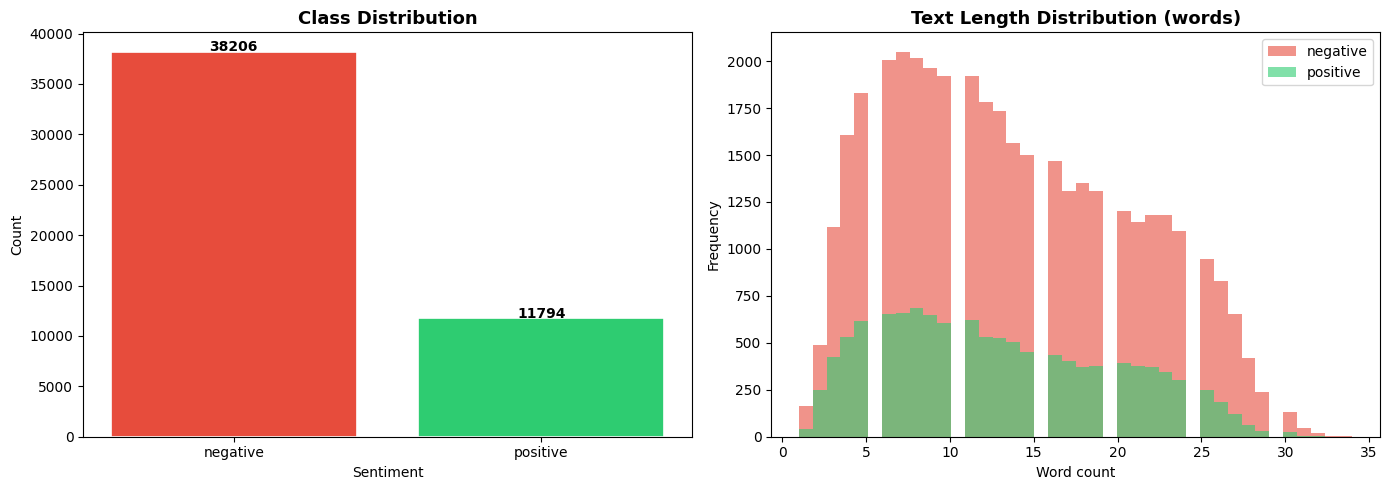

Mean text length : 13.4 words
Median text length: 12.0 words
95th percentile  : 26 words


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution bar chart
counts = df['sentiment'].value_counts()
palette = {'positive': '#2ecc71', 'neutral': '#3498db', 'negative': '#e74c3c'}
axes[0].bar(counts.index, counts.values,
            color=[palette[s] for s in counts.index], edgecolor='white', linewidth=1.2)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentiment'); axes[0].set_ylabel('Count')
for i, (idx, val) in enumerate(counts.items()):
    axes[0].text(i, val + 30, str(val), ha='center', fontweight='bold')

# Text length distribution
df['text_len'] = df['text'].str.split().str.len()
for sent, grp in df.groupby('sentiment'):
    axes[1].hist(grp['text_len'], bins=40, alpha=0.6,
                 label=sent, color=palette[sent])
axes[1].set_title('Text Length Distribution (words)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word count'); axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Mean text length : {df['text_len'].mean():.1f} words")
print(f"Median text length: {df['text_len'].median():.1f} words")
print(f"95th percentile  : {df['text_len'].quantile(0.95):.0f} words")

## Step 7 — Train / Validation / Test Split

In [13]:
# Cap at 20 000 samples to keep training fast on Colab free tier
MAX_SAMPLES = 20_000
if len(df) > MAX_SAMPLES:
    df = df.groupby('sentiment', group_keys=False).apply(
        lambda x: x.sample(min(len(x), MAX_SAMPLES // 3), random_state=SEED)
    ).reset_index(drop=True)
    print(f'Down-sampled to {len(df)} rows (balanced)')

# 70 / 15 / 15 stratified split
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['label'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED
)

for name, d in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f'{name:5s}: {len(d):5d} rows | {d["sentiment"].value_counts().to_dict()}')

Down-sampled to 13332 rows (balanced)
Train:  9332 rows | {'positive': 4666, 'negative': 4666}
Val  :  2000 rows | {'positive': 1000, 'negative': 1000}
Test :  2000 rows | {'negative': 1000, 'positive': 1000}


## Step 8 — Tokenisation

In [14]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN    = 128

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
print(f'Tokeniser loaded: {MODEL_NAME}')

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding='max_length',
            max_length=max_len,
            return_tensors='pt'
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx]
        }

BATCH_SIZE = 32

train_ds = SentimentDataset(train_df['text'], train_df['label'], tokenizer, MAX_LEN)
val_ds   = SentimentDataset(val_df['text'],   val_df['label'],   tokenizer, MAX_LEN)
test_ds  = SentimentDataset(test_df['text'],  test_df['label'],  tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokeniser loaded: distilbert-base-uncased
Train batches: 292 | Val batches: 63 | Test batches: 63


## Step 9 — Load Pre-trained DistilBERT & Add Classifier Head

DistilBERT is a distilled (smaller, faster) version of BERT that retains ~97 % of BERT's performance at 60 % of its size.

In [15]:
NUM_CLASSES = 3

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    id2label=ID2LABEL,
    label2id=LABEL2ID
).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total:,}')
print(f'Trainable parameters: {trainable:,}')
print(f'Architecture: {MODEL_NAME} + 3-class linear head')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters    : 66,955,779
Trainable parameters: 66,955,779
Architecture: distilbert-base-uncased + 3-class linear head


## Step 10 — Training Setup

In [16]:
EPOCHS       = 4
LR           = 2e-5
WARMUP_RATIO = 0.1

optimizer    = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f'Epochs          : {EPOCHS}')
print(f'Total steps     : {total_steps}')
print(f'Warmup steps    : {warmup_steps}')
print(f'Learning rate   : {LR}')

Epochs          : 4
Total steps     : 1168
Warmup steps    : 116
Learning rate   : 2e-05


## Step 11 — Training & Validation Loop

In [17]:
def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        input_ids  = batch['input_ids'].to(device)
        attn_mask  = batch['attention_mask'].to(device)
        labels     = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attn_mask, labels=labels)
        loss    = outputs.loss
        loss.backward()

        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * labels.size(0)
        preds       = outputs.logits.argmax(dim=-1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attn_mask = batch['attention_mask'].to(device)
        labels    = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attn_mask, labels=labels)
        total_loss += outputs.loss.item() * labels.size(0)
        preds       = outputs.logits.argmax(dim=-1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / total, correct / total


# ── Training loop ─────────────────────────────────────────────────────────────
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc, best_state = 0.0, None

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, scheduler)
    vl_loss, vl_acc = eval_epoch(model, val_loader)

    history['train_loss'].append(tr_loss)
    history['train_acc' ].append(tr_acc)
    history['val_loss'  ].append(vl_loss)
    history['val_acc'   ].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(f'Epoch {epoch}/{EPOCHS}  '
          f'Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f}  |  '
          f'Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}')

# Restore best checkpoint
model.load_state_dict(best_state)
print(f'\nBest validation accuracy: {best_val_acc:.4f}')

Epoch 1/4  Train Loss: 0.5994  Acc: 0.7126  |  Val Loss: 0.4302  Acc: 0.8040
Epoch 2/4  Train Loss: 0.3626  Acc: 0.8506  |  Val Loss: 0.4257  Acc: 0.8095
Epoch 3/4  Train Loss: 0.2657  Acc: 0.8988  |  Val Loss: 0.4860  Acc: 0.8080
Epoch 4/4  Train Loss: 0.1927  Acc: 0.9338  |  Val Loss: 0.5334  Acc: 0.8075

Best validation accuracy: 0.8095


## Step 12 — Plot Training Curves

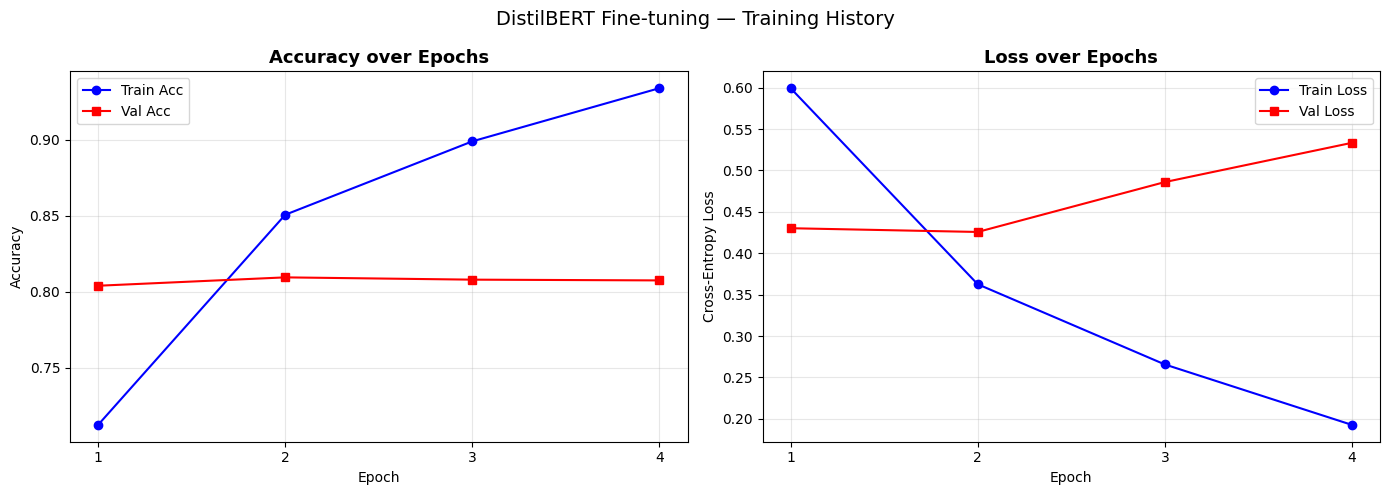

In [18]:
epochs_x = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_x, history['train_acc'], 'b-o', ms=6, label='Train Acc')
ax1.plot(epochs_x, history['val_acc'],   'r-s', ms=6, label='Val Acc')
ax1.set_title('Accuracy over Epochs', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)
ax1.set_xticks(list(epochs_x))

ax2.plot(epochs_x, history['train_loss'], 'b-o', ms=6, label='Train Loss')
ax2.plot(epochs_x, history['val_loss'],   'r-s', ms=6, label='Val Loss')
ax2.set_title('Loss over Epochs', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Cross-Entropy Loss')
ax2.legend(); ax2.grid(alpha=0.3)
ax2.set_xticks(list(epochs_x))

plt.suptitle('DistilBERT Fine-tuning — Training History', fontsize=14)
plt.tight_layout()
plt.show()

## Step 13 — Evaluation on Test Set

In [25]:
@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attn_mask = batch['attention_mask'].to(device)
        labels    = batch['labels']
        outputs   = model(input_ids=input_ids, attention_mask=attn_mask)
        probs     = torch.softmax(outputs.logits, dim=-1).cpu()
        preds     = probs.argmax(dim=-1)
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

y_true, y_pred, y_probs = get_predictions(model, test_loader)
label_names = [ID2LABEL[i] for i in sorted(ID2LABEL)]

print('=' * 60)
print('       CLASSIFICATION REPORT — Test Set')
print('=' * 60)
print(classification_report(
    y_true,
    y_pred,
    labels=[0, 1, 2],
    target_names=['negative', 'neutral', 'positive'],
    digits=4
))

       CLASSIFICATION REPORT — Test Set
              precision    recall  f1-score   support

    negative     0.8017    0.8290    0.8151      1000
     neutral     0.0000    0.0000    0.0000         0
    positive     0.8230    0.7950    0.8087      1000

    accuracy                         0.8120      2000
   macro avg     0.5416    0.5413    0.5413      2000
weighted avg     0.8124    0.8120    0.8119      2000



## Step 14 — Confusion Matrix

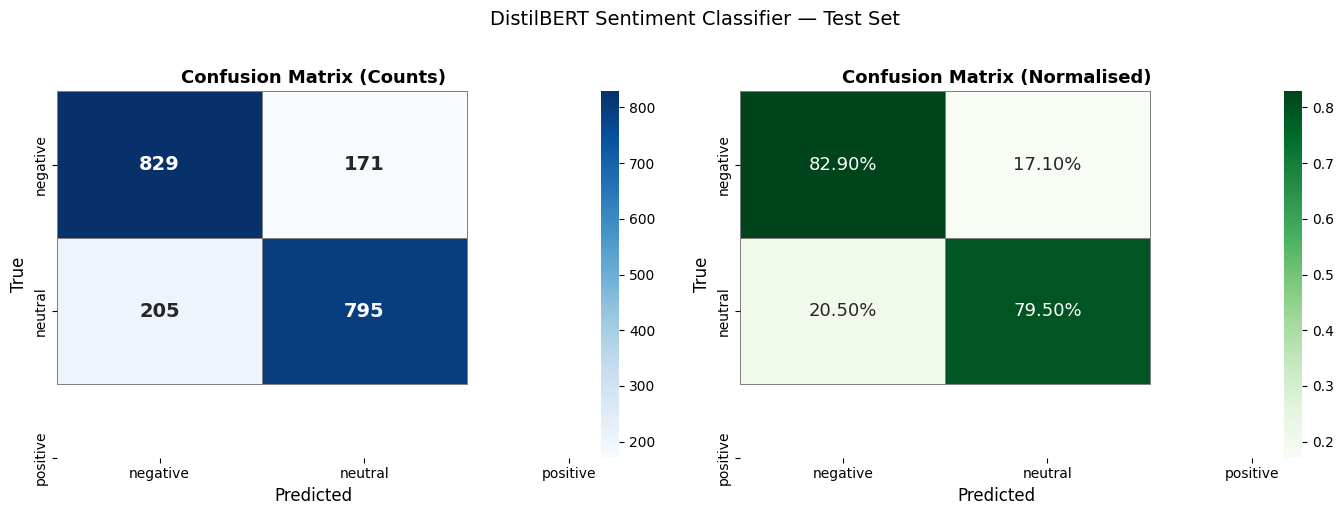

Overall Test Accuracy: 0.8120 (81.20%)


In [26]:
cm = confusion_matrix(y_true, y_pred)

# Raw counts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names,
            linewidths=0.5, linecolor='grey',
            annot_kws={'size': 14, 'weight': 'bold'},
            ax=axes[0])
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('True', fontsize=12)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')

# Normalised
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=label_names, yticklabels=label_names,
            linewidths=0.5, linecolor='grey',
            annot_kws={'size': 13},
            ax=axes[1])
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('True', fontsize=12)
axes[1].set_title('Confusion Matrix (Normalised)', fontsize=13, fontweight='bold')

plt.suptitle('DistilBERT Sentiment Classifier — Test Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

test_acc = (y_true == y_pred).mean()
print(f'Overall Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')

## Step 15 — Per-class Confidence Distribution

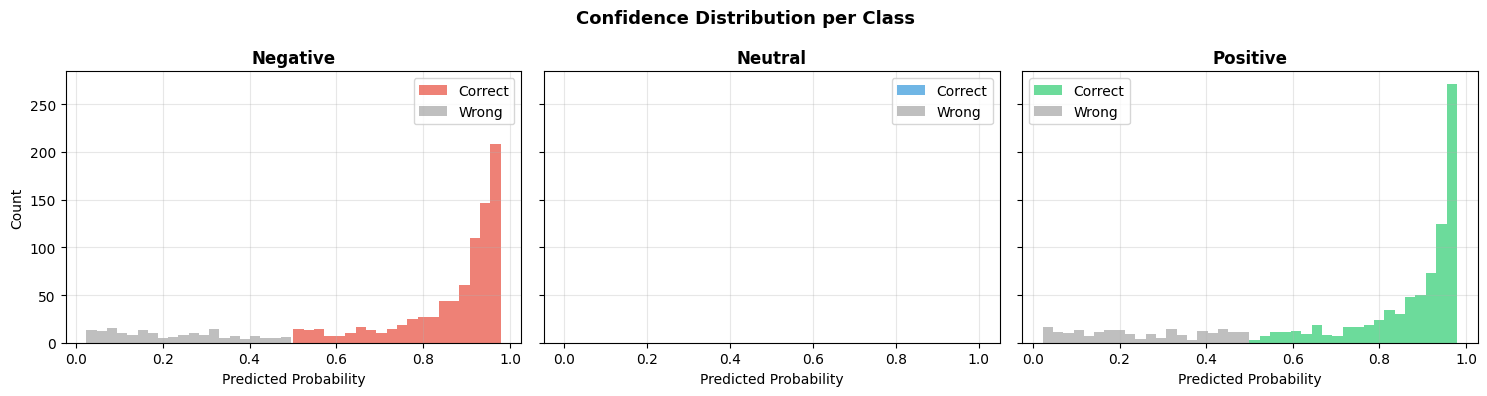

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
palette   = ['#e74c3c', '#3498db', '#2ecc71']

for idx, (label, color) in enumerate(zip(label_names, palette)):
    mask     = y_true == idx
    conf_correct = y_probs[mask & (y_pred == y_true), idx]
    conf_wrong   = y_probs[mask & (y_pred != y_true), idx]

    axes[idx].hist(conf_correct, bins=20, alpha=0.7, color=color, label='Correct')
    axes[idx].hist(conf_wrong,   bins=20, alpha=0.5, color='grey', label='Wrong')
    axes[idx].set_title(f'{label.capitalize()}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted Probability')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

axes[0].set_ylabel('Count')
plt.suptitle('Confidence Distribution per Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 16 — Inspect Misclassified Examples

In [28]:
test_texts = test_df['text'].reset_index(drop=True)
wrong_mask = y_true != y_pred

wrong_df = pd.DataFrame({
    'text':       test_texts[wrong_mask].values,
    'true_label': [ID2LABEL[i] for i in y_true[wrong_mask]],
    'pred_label': [ID2LABEL[i] for i in y_pred[wrong_mask]],
    'confidence': y_probs[wrong_mask].max(axis=1).round(3)
})

print(f'Misclassified: {len(wrong_df)} / {len(y_true)} ({len(wrong_df)/len(y_true)*100:.1f}%)')
print('\nSample misclassifications:')
wrong_df.sample(min(10, len(wrong_df)), random_state=SEED)[['text', 'true_label', 'pred_label', 'confidence']]

Misclassified: 376 / 2000 (18.8%)

Sample misclassifications:


,text,true_label,pred_label,confidence
290,"@Cyberela I feel better now, thanx",positive,negative,0.609
357,@TatianaToT oh yeahhh 3891 Exclusive Clothing ...,positive,negative,0.810
261,@AndresAlanJaime from my understanding she was...,negative,positive,0.960
157,"@mycatranch sorry about that, &quot;Demyx&quot...",positive,negative,0.889
145,"yay, another day at work",negative,positive,0.918
90,"Uh Oh, I start making bad typos. I think it ma...",positive,negative,0.855
132,@missgiggly I shall be looking,positive,negative,0.523
57,Surprised me with Military Ball tickets.,positive,negative,0.559
76,Home alone watching ncis,positive,negative,0.644
363,"Pasta for dinner. Yum. Tonight, I'm going to ...",positive,negative,0.809


## Step 17 — Save Model & Tokeniser

In [29]:
SAVE_DIR = './sentiment_distilbert'
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f'Model and tokeniser saved to {SAVE_DIR}/')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokeniser saved to ./sentiment_distilbert/


## Step 18 — Inference on Custom Text

In [30]:
@torch.no_grad()
def predict_sentiment(texts, model, tokenizer, max_len=128):
    """
    Predict sentiment for a list of strings.
    Returns list of dicts with 'label' and per-class probabilities.
    """
    if isinstance(texts, str):
        texts = [texts]

    model.eval()
    encoding = tokenizer(
        texts, truncation=True, padding='max_length',
        max_length=max_len, return_tensors='pt'
    )
    input_ids = encoding['input_ids'].to(device)
    attn_mask = encoding['attention_mask'].to(device)

    logits = model(input_ids=input_ids, attention_mask=attn_mask).logits
    probs  = torch.softmax(logits, dim=-1).cpu().numpy()

    results = []
    for text, prob in zip(texts, probs):
        pred = int(prob.argmax())
        results.append({
            'text':      text[:80] + ('...' if len(text) > 80 else ''),
            'label':     ID2LABEL[pred],
            'negative':  round(float(prob[0]), 4),
            'neutral':   round(float(prob[1]), 4),
            'positive':  round(float(prob[2]), 4),
        })
    return pd.DataFrame(results)


# ── Demo predictions ──────────────────────────────────────────────────────────
demo_texts = [
    "I absolutely love this product! It works perfectly and exceeded all my expectations.",
    "The package arrived on time. Nothing special to report.",
    "Terrible experience. The item broke after one day and customer support was useless.",
    "It's okay I guess, does what it says on the tin.",
    "Wow, best purchase I've made all year! Highly recommend to everyone!",
    "I'm really disappointed. Expected much better quality for this price."
]

results = predict_sentiment(demo_texts, model, tokenizer)
print('\n── Custom Inference Results ──')
pd.set_option('display.max_colwidth', 60)
results


── Custom Inference Results ──


,text,label,negative,neutral,positive
0,I absolutely love this product! It works perfectly and e...,positive,0.0363,0.0026,0.9611
1,The package arrived on time. Nothing special to report.,negative,0.7654,0.0023,0.2323
2,Terrible experience. The item broke after one day and cu...,negative,0.9710,0.0031,0.0260
3,"It's okay I guess, does what it says on the tin.",positive,0.1227,0.0025,0.8748
4,"Wow, best purchase I've made all year! Highly recommend ...",positive,0.0209,0.0027,0.9764
5,I'm really disappointed. Expected much better quality fo...,negative,0.9674,0.0015,0.0311
